# Метрика скорости реализации интента


**Окно:** `2024-03-04 … 2024-03-10` (полная рабочая неделя).

**Допущение №1 ** в данных нет события `order`. Используем `to_cart` как прокси целевого действия — это ключевое ограничение

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import date, timedelta

sns.set_theme(style='whitegrid', context='notebook')
pl.Config.set_tbl_rows(20)

DATA = Path('data/user_actions_3_months')
PRODUCTS = Path('data/product_information')

WEEK_START = date(2024, 3, 4)
WEEK_END   = date(2024, 3, 10)
SESSION_GAP_MIN = 30  # стартовый порог, пересмотрим ниже по распределению gap

## 1. Загрузка недели событий

Hive-партиционирование (`date=.../action_type=...`) читаем через `scan_parquet` лениво, материализуем только нужный диапазон. `product_information` грузим целиком — он маленький (130к строк).

In [29]:
events = (
    pl.scan_parquet(str(DATA) + '/**/*.parquet', hive_partitioning=True)
      .filter((pl.col('date') >= WEEK_START) & (pl.col('date') <= WEEK_END))
      .collect()
)
print('total events in week:', f'{events.height:,}')
events.head()

total events in week: 75,952,133


user_id,date,timestamp,action_type,widget_name,search_query,item_id
i32,date,datetime[ns],str,str,str,i32
7704439,2024-03-04,2024-03-04 16:08:51,"""click""","""search_catalog_listing""","""макаруни""",93293
8778297,2024-03-04,2024-03-04 15:58:47,"""click""","""search_catalog_listing""","""mix bar орехи с цукатами""",89490
6350523,2024-03-04,2024-03-04 13:10:31,"""click""","""search_catalog_listing""","""зубная паста""",241092
326552,2024-03-04,2024-03-04 02:50:04,"""click""","""search_catalog_listing""","""геркулес""",235591
3405860,2024-03-04,2024-03-04 19:23:57,"""click""","""search_catalog_listing""","""нерка""",187677


In [30]:
products = pl.read_parquet(str(PRODUCTS))
print('products:', f'{products.height:,}')
products.head()

products: 130,035


item_id,name,brand,type,category_id,category_name
i32,str,str,str,i32,str
12291,"""Витамин С 1200 мг Эвалар, для …","""Эвалар""","""Витаминный комплекс""",761,"""Витамин C"""
178066,"""Nature's Bounty Эстер-С 500мг …","""Nature's Bounty""","""Витамины""",761,"""Витамин C"""
169337,"""Доппельгерц Актив Витамин C + …","""Доппельгерц / Doppelherz""","""Витаминный комплекс""",761,"""Витамин C"""
226982,"""Витаминный комплекс Бэби Форму…","""Эвалар""","""Витаминный комплекс""",761,"""Витамин C"""
220079,"""Maxler Vitamin C (Sodium Ascor…","""Maxler""","""Витамины""",761,"""Витамин C"""


## 2. Базовые объёмы и структура

Смотрим, как распределены события по типу, по дням и по виджетам — это задаёт ориентиры для сессионизации и выбора таргета.

In [31]:
by_type = events.group_by('action_type').agg(pl.len().alias('n')).sort('n', descending=True)
by_type.with_columns((pl.col('n') / pl.col('n').sum() * 100).round(2).alias('pct'))

action_type,n,pct
str,u32,f64
"""view""",67881163,89.37
"""search""",4136847,5.45
"""to_cart""",2229843,2.94
"""click""",1638497,2.16
"""favorite""",65783,0.09


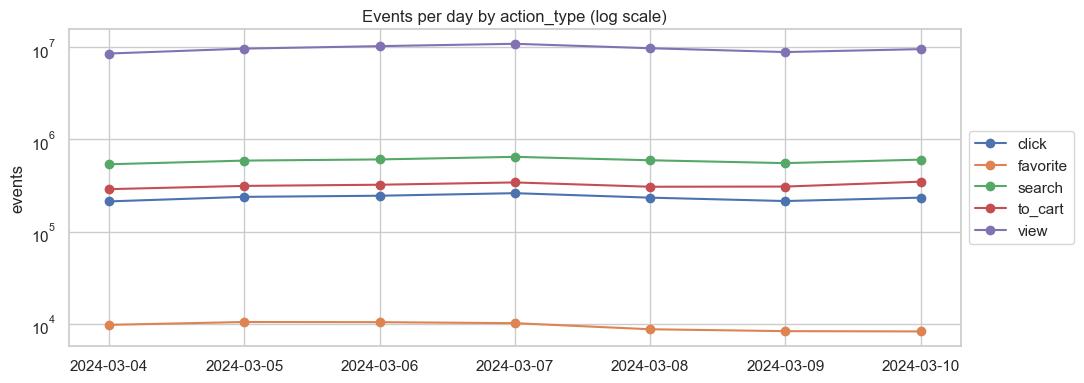

In [32]:
daily = (
    events.group_by(['date', 'action_type'])
          .agg(pl.len().alias('n'))
          .sort(['date', 'action_type'])
          .to_pandas()
)
fig, ax = plt.subplots(figsize=(11, 4))
for at, sub in daily.groupby('action_type'):
    ax.plot(sub['date'], sub['n'], marker='o', label=at)
ax.set_yscale('log')
ax.set_title('Events per day by action_type (log scale)')
ax.set_ylabel('events')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout(); plt.show()

In [34]:
# widget_name в разрезе типов событий — где случается поиск и где куда кладут в корзину
(
    events.group_by(['action_type', 'widget_name'])
          .agg(pl.len().alias('n'))
          .sort(['action_type', 'n'], descending=[False, True])
)

action_type,widget_name,n
str,str,u32
"""click""","""search_catalog_listing""",1638497
"""favorite""","""search_catalog_listing""",37852
"""favorite""","""product_detailed_page""",27931
"""search""","""search_suggestions""",2399137
"""search""","""mobile_search_bar""",1503023
"""search""","""search_history""",130813
"""search""","""web_search_bar""",103874
"""to_cart""","""search_catalog_listing""",1853221
"""to_cart""","""product_detailed_page""",376622


**Что ищем в этих таблицах:**
- Доля `to_cart` от `search_catalog_listing` vs `product_detailed_page` — это две принципиально разные поверхности успеха (поиск vs карточка товара). В метрике считаем атрибутированные к поиску.
- Виджеты search (`search_suggestions`, `mobile_search_bar`, `search_history`, `web_search_bar`) — потенциальные разрезы для выводов про работу саджестов.

## 3. Inter-event gap -> выбор порога сессии

Нет `session_id`, поэтому режем по неактивности. Хороший порог — точка «долины» между внутрисессионной активностью (секунды-минуты) и межсессионной (часы-сутки). Обычно около 20–40 минут.

In [35]:
# Для скорости берём случайную выборку 200k пользователей
rng = np.random.default_rng(42)
sample_users = events.select('user_id').unique().to_series().to_numpy()
sample_users = rng.choice(sample_users, size=min(200_000, len(sample_users)), replace=False)

gaps = (
    events.filter(pl.col('user_id').is_in(sample_users))
          .sort(['user_id', 'timestamp'])
          .with_columns(
              (pl.col('timestamp').diff().over('user_id')
                 .dt.total_seconds() / 60).alias('gap_min')
          )
          .filter(pl.col('gap_min').is_not_null() & (pl.col('gap_min') > 0))
          .select('gap_min')
          .to_series()
          .to_numpy()
)
print('gap sample size:', f'{len(gaps):,}')
print('median:', np.median(gaps), 'min | p90:', np.percentile(gaps, 90), 'min')

gap sample size: 6,953,194
median: 0.03333333333333333 min | p90: 0.31666666666666665 min


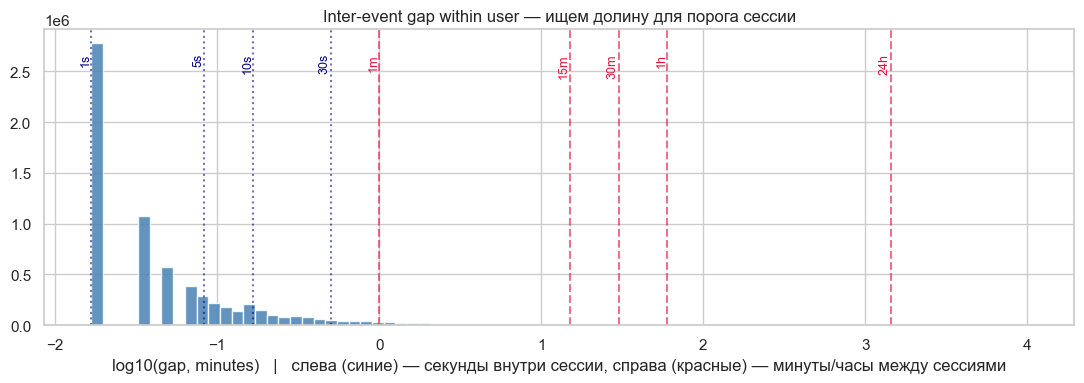

In [36]:
# Log-histogram — классика для поиска долины между внутри- и межсессионными паузами
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(np.log10(np.clip(gaps, 1/60, None)), bins=80, color='steelblue', alpha=0.85)

# Отметки в секундах (внутрисессионные паузы) — синим
sec_marks = [(1, '1s'), (5, '5s'), (10, '10s'), (30, '30s')]
for t_sec, label in sec_marks:
    ax.axvline(np.log10(t_sec/60), ls=':', color='navy', alpha=0.55)
    ax.text(np.log10(t_sec/60), ax.get_ylim()[1]*0.92, label,
            rotation=90, va='top', ha='right', color='navy', fontsize=9)

# Отметки в минутах/часах (межсессионные паузы) — красным
min_marks = [(1, '1m'), (15, '15m'), (30, '30m'), (60, '1h'), (60*24, '24h')]
for t_min, label in min_marks:
    ax.axvline(np.log10(t_min), ls='--', color='crimson', alpha=0.6)
    ax.text(np.log10(t_min), ax.get_ylim()[1]*0.92, label,
            rotation=90, va='top', ha='right', color='crimson', fontsize=9)

ax.set_xlabel('log10(gap, minutes)   |   слева (синие) — секунды внутри сессии, справа (красные) — минуты/часы между сессиями')
ax.set_title('Inter-event gap within user — ищем долину для порога сессии')
plt.tight_layout(); plt.show()

**Интерпретация:** первая мода — активные секундные интервалы (клики/просмотры внутри сессии), вторая — возвраты через часы/сутки. Точка минимума между ними — разумный порог. По умолчанию берём 30 минут, но роль Data Engineer должна зафиксировать это окончательно.

## 4. Сессионизация и таблица `intent_sessions`

Для каждого пользователя ставим `session_id = cumsum(gap > threshold)`. Затем агрегируем одну строку на сессию с фичами, нужными метрикам.

In [37]:
gap_thresh = SESSION_GAP_MIN * 60  # сек

ev = (
    events.sort(['user_id', 'timestamp'])
          .with_columns(
              (pl.col('timestamp').diff().over('user_id').dt.total_seconds()
                 .fill_null(gap_thresh + 1) > gap_thresh).alias('new_session')
          )
          .with_columns(pl.col('new_session').cast(pl.Int32).cum_sum().over('user_id').alias('session_idx'))
)
ev.select(['user_id', 'timestamp', 'action_type', 'search_query', 'new_session', 'session_idx']).head(10)

user_id,timestamp,action_type,search_query,new_session,session_idx
i32,datetime[ns],str,str,bool,i32
37,2024-03-07 20:25:29,"""view""","""торт шоколадный""",true,1
37,2024-03-07 20:25:29,"""search""","""торт шоколадный""",false,1
37,2024-03-07 20:25:29,"""view""","""торт шоколадный""",false,1
37,2024-03-07 20:25:29,"""view""","""торт шоколадный""",false,1
37,2024-03-07 20:25:29,"""view""","""торт шоколадный""",false,1
37,2024-03-07 20:25:30,"""view""","""торт шоколадный""",false,1
37,2024-03-07 20:25:30,"""view""","""торт шоколадный""",false,1
37,2024-03-07 20:25:41,"""search""","""торт птичье молоко""",false,1
37,2024-03-07 20:25:41,"""view""","""торт птичье молоко""",false,1


In [38]:
# Вытягиваем последний непустой search_query как активный интент для каждого события в сессии.
# Это простая прокси-атрибуция: view/click/cart относим к предшествующему search_query.
ev = ev.with_columns(
    pl.when(pl.col('action_type') == 'search')
      .then(pl.col('search_query'))
      .otherwise(None)
      .alias('_q')
).with_columns(
    pl.col('_q').forward_fill().over(['user_id', 'session_idx']).alias('active_query')
).drop('_q')

ev.select(['user_id','session_idx','timestamp','action_type','search_query','active_query']).head(10)

user_id,session_idx,timestamp,action_type,search_query,active_query
i32,i32,datetime[ns],str,str,str
37,1,2024-03-07 20:25:29,"""view""","""торт шоколадный""",null
37,1,2024-03-07 20:25:29,"""search""","""торт шоколадный""","""торт шоколадный"""
37,1,2024-03-07 20:25:29,"""view""","""торт шоколадный""","""торт шоколадный"""
37,1,2024-03-07 20:25:29,"""view""","""торт шоколадный""","""торт шоколадный"""
37,1,2024-03-07 20:25:29,"""view""","""торт шоколадный""","""торт шоколадный"""
37,1,2024-03-07 20:25:30,"""view""","""торт шоколадный""","""торт шоколадный"""
37,1,2024-03-07 20:25:30,"""view""","""торт шоколадный""","""торт шоколадный"""
37,1,2024-03-07 20:25:41,"""search""","""торт птичье молоко""","""торт птичье молоко"""
37,1,2024-03-07 20:25:41,"""view""","""торт птичье молоко""","""торт птичье молоко"""


In [39]:
sessions = (
    ev.group_by(['user_id', 'session_idx'])
      .agg([
          pl.col('timestamp').min().alias('ts_start'),
          pl.col('timestamp').max().alias('ts_end'),
          pl.len().alias('n_events'),
          (pl.col('action_type') == 'search').sum().alias('n_search'),
          (pl.col('action_type') == 'view').sum().alias('n_view'),
          (pl.col('action_type') == 'click').sum().alias('n_click'),
          (pl.col('action_type') == 'to_cart').sum().alias('n_cart'),
          (pl.col('action_type') == 'favorite').sum().alias('n_fav'),
          pl.col('search_query').filter(pl.col('action_type') == 'search').n_unique().alias('n_unique_queries'),
          pl.col('search_query').filter(pl.col('action_type') == 'search').drop_nulls().first().alias('first_query'),
          pl.col('widget_name').filter(pl.col('action_type') == 'search').drop_nulls().first().alias('first_widget'),
      ])
      .with_columns([
          (pl.col('ts_end') - pl.col('ts_start')).dt.total_seconds().alias('duration_s'),
          (pl.col('n_cart') > 0).alias('reached_cart'),
      ])
)

# Оставляем только сессии с хотя бы одним search — остальное к нашей метрике не относится.
intent_sessions = sessions.filter(pl.col('n_search') > 0)
print('sessions total:', f'{sessions.height:,}')
print('intent-sessions (>=1 search):', f'{intent_sessions.height:,}')
intent_sessions.head()

sessions total: 1,407,868
intent-sessions (>=1 search): 1,195,741


user_id,session_idx,ts_start,ts_end,n_events,n_search,n_view,n_click,n_cart,n_fav,n_unique_queries,first_query,first_widget,duration_s,reached_cart
i32,i32,datetime[ns],datetime[ns],u32,u32,u32,u32,u32,u32,u32,str,str,i64,bool
4120882,3,2024-03-09 22:43:49,2024-03-09 22:43:50,3,1,2,0,0,0,1,"""фрутоняня индейка""","""mobile_search_bar""",1,false
5013253,12,2024-03-10 13:46:21,2024-03-10 14:00:31,106,3,102,0,0,1,3,"""набор подарочный""","""search_suggestions""",850,false
4731490,2,2024-03-05 16:46:35,2024-03-05 16:50:34,46,3,39,1,3,0,3,"""горошек консервированный""","""search_suggestions""",239,true
9463100,1,2024-03-09 18:33:59,2024-03-09 18:41:41,104,13,80,0,11,0,13,"""молоко""","""search_suggestions""",462,true
6512129,1,2024-03-06 10:39:30,2024-03-06 10:39:52,75,1,74,0,0,0,1,"""нутрилон каша""","""mobile_search_bar""",22,false


In [40]:
# Time-to-cart: от первого события сессии до первого to_cart
cart_ts = (
    ev.filter(pl.col('action_type') == 'to_cart')
      .group_by(['user_id', 'session_idx'])
      .agg(pl.col('timestamp').min().alias('ts_first_cart'))
)
intent_sessions = intent_sessions.join(cart_ts, on=['user_id','session_idx'], how='left').with_columns(
    (pl.col('ts_first_cart') - pl.col('ts_start')).dt.total_seconds().alias('time_to_cart_s')
)
intent_sessions.select(['user_id','session_idx','n_search','n_unique_queries','n_view','reached_cart','time_to_cart_s','duration_s']).head()

user_id,session_idx,n_search,n_unique_queries,n_view,reached_cart,time_to_cart_s,duration_s
i32,i32,u32,u32,u32,bool,i64,i64
4120882,3,1,1,2,false,null,1
5013253,12,3,3,102,false,null,850
4731490,2,3,3,39,true,88,239
9463100,1,13,13,80,true,8,462
6512129,1,1,1,74,false,null,22


## 5. Success rate и распределения кандидатов в метрику

Считаем три ветки и смотрим как они распределены на успешных сессиях:
- **Query-Depth** (QD) — `n_unique_queries` до первого `to_cart`.
- **Time-to-Cart** (TTC) — секунды.
- **Effort Score** — композит в лог-шкале.

In [41]:
sr = intent_sessions['reached_cart'].mean()
print(f'Success rate (sessions reaching to_cart): {sr:.2%}')

succ = intent_sessions.filter(pl.col('reached_cart')).to_pandas()
fail = intent_sessions.filter(~pl.col('reached_cart')).to_pandas()
print('successful:', len(succ), '| failed:', len(fail))

Success rate (sessions reaching to_cart): 45.34%
successful: 542206 | failed: 653535


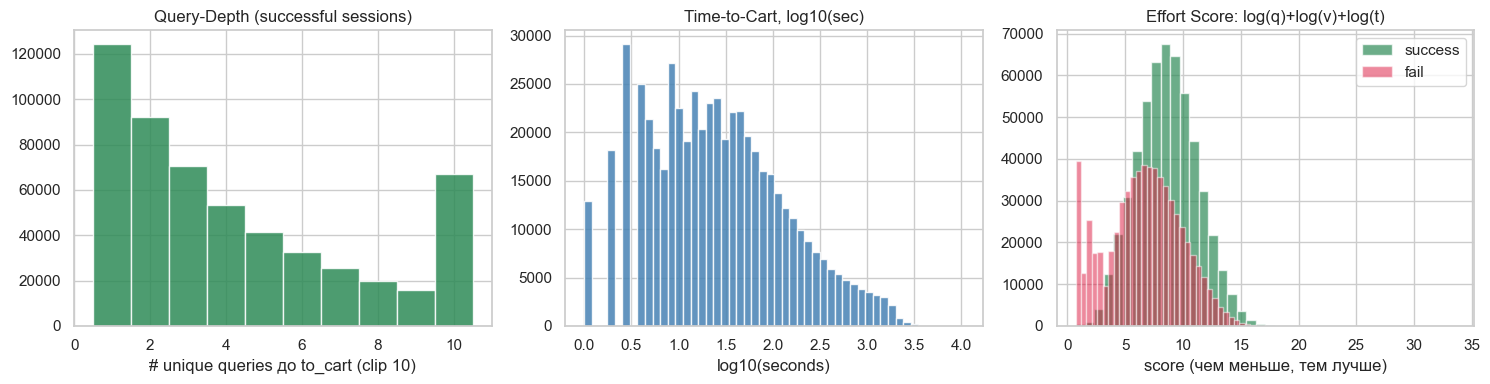

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(succ['n_unique_queries'].clip(upper=10), bins=np.arange(0.5, 11.5, 1), color='seagreen', alpha=0.85)
axes[0].set_title('Query-Depth (successful sessions)')
axes[0].set_xlabel('# unique queries до to_cart (clip 10)')

ttc = np.log10(np.clip(succ['time_to_cart_s'].dropna().values, 1, None))
axes[1].hist(ttc, bins=50, color='steelblue', alpha=0.85)
axes[1].set_title('Time-to-Cart, log10(sec)')
axes[1].set_xlabel('log10(seconds)')

def effort(df):
    q = np.log1p(df['n_unique_queries'].fillna(0))
    v = np.log1p(df['n_view'].fillna(0))
    t = np.log1p(df['time_to_cart_s'].fillna(df['duration_s']).clip(lower=0))
    return q + v + t

axes[2].hist(effort(succ), bins=40, color='seagreen', alpha=0.7, label='success')
axes[2].hist(effort(fail), bins=40, color='crimson',  alpha=0.5, label='fail')
axes[2].set_title('Effort Score: log(q)+log(v)+log(t)')
axes[2].set_xlabel('score (чем меньше, тем лучше)')
axes[2].legend()
plt.tight_layout(); plt.show()

**На что смотреть:**
- Если QD-распределение на успешных сессиях имеет длинный хвост — значит поиск часто требует уточнений (целевая точка приложения усилий команды поиска).
- Разделимость `success` vs `fail` по Effort говорит о том, насколько композит работает как сигнал — это материал для ROC/PR в роли Metric Scientist.
- Медиана TTC per-category понадобится для калибровки (FMCG vs Electronics).

## 6. Разрез по `widget_name` первого поискового события

Гипотеза: сессии, начатые из `search_suggestions`, конвертятся лучше (система уже угадала интент) чем ручной ввод `mobile_search_bar`.

In [43]:
by_widget = (
    intent_sessions.group_by('first_widget').agg([
        pl.len().alias('sessions'),
        pl.col('reached_cart').mean().alias('success_rate'),
        pl.col('n_unique_queries').median().alias('median_QD'),
        pl.col('time_to_cart_s').median().alias('median_TTC_s'),
    ]).sort('sessions', descending=True)
)
by_widget

first_widget,sessions,success_rate,median_QD,median_TTC_s
str,u32,f64,f64,f64
"""search_suggestions""",733809,0.473648,2.0,21.0
"""mobile_search_bar""",382642,0.42038,2.0,25.0
"""search_history""",52871,0.466778,1.0,21.0
"""web_search_bar""",26419,0.344638,1.0,28.0


## 7. Первый взгляд


Быстрые эвристики:
- **Zero-result** — search без единого view/click в той же сессии.
- **Длинный запрос** (>6 токенов).
- **Латиница** — чисто латинские запросы (английские бренды).

Всё это — сырой вход для роли NLP и ML Researcher, здесь я только показываю, что сигнал есть.

In [44]:
searches = (
    ev.filter(pl.col('action_type') == 'search')
      .with_columns([
          pl.col('search_query').str.split(' ').list.len().alias('n_tokens'),
          pl.col('search_query').str.contains(r'^[a-zA-Z0-9 \-]+$').alias('is_latin'),
          pl.col('search_query').str.len_chars().alias('q_len'),
      ])
)

# Zero-result: в сессии после search ничего из этого search_query не переросло в view/click
post_search_activity = (
    ev.filter(pl.col('action_type').is_in(['view','click','to_cart','favorite']))
      .group_by(['user_id','session_idx','active_query'])
      .agg(pl.len().alias('downstream_n'))
      .rename({'active_query':'search_query'})
)
q_level = (
    searches.group_by(['user_id','session_idx','search_query'])
            .agg([
                pl.col('n_tokens').first(),
                pl.col('is_latin').first(),
                pl.col('q_len').first(),
            ])
            .join(post_search_activity, on=['user_id','session_idx','search_query'], how='left')
            .with_columns((pl.col('downstream_n').fill_null(0) == 0).alias('zero_result'))
)
print('unique search queries in week:', f'{q_level.height:,}')
print('zero-result share:', f"{q_level['zero_result'].mean():.2%}")
print('latin share:', f"{q_level['is_latin'].mean():.2%}")
print('long (>6 tokens) share:', f"{(q_level['n_tokens'] > 6).mean():.2%}")

unique search queries in week: 3,805,237
zero-result share: 6.21%
latin share: 3.53%
long (>6 tokens) share: 0.40%


In [45]:
# Zero-result rate в разрезе длины запроса — первый слайд для презентации
bucket = (
    q_level.with_columns(
        pl.when(pl.col('n_tokens') == 1).then(pl.lit('1'))
          .when(pl.col('n_tokens').is_between(2,3)).then(pl.lit('2-3'))
          .when(pl.col('n_tokens').is_between(4,6)).then(pl.lit('4-6'))
          .otherwise(pl.lit('7+')).alias('tok_bucket')
    )
    .group_by('tok_bucket')
    .agg([
        pl.len().alias('queries'),
        pl.col('zero_result').mean().alias('zero_result_rate'),
        pl.col('is_latin').mean().alias('latin_share'),
    ])
    .sort('tok_bucket')
)
bucket

tok_bucket,queries,zero_result_rate,latin_share
str,u32,f64,f64
"""1""",1419068,0.065925,0.055914
"""2-3""",1924918,0.050129,0.026088
"""4-6""",441428,0.085409,0.010559
"""7+""",19823,0.437825,0.005123


In [46]:
# Zero-result vs язык запроса
(
    q_level.group_by('is_latin').agg([
        pl.len().alias('queries'),
        pl.col('zero_result').mean().alias('zero_result_rate'),
    ])
)

is_latin,queries,zero_result_rate
bool,u32,f64
false,3666338,0.056727
null,4597,1.0
true,134302,0.17757


In [47]:
out = Path('data/intent_sessions_week.parquet')
intent_sessions.write_parquet(out)
print('saved:', out, '| rows:', intent_sessions.height)

saved: data/intent_sessions_week.parquet | rows: 1195741
